# xCounter — Modelagem (Regressão Logística): o FM agrega poder preditivo?

**Disciplina:** COE609 — Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

Modelo: **regressão logística** (melhor que árvores nesta base pequena e quase-linear,
conforme comparação prévia). Treino nas **linhas completas** (sem imputação).

## Pergunta central
As features físicas do FM **agregam** poder preditivo ao xCounter? Testamos via
**ablação**:
- **M1 (espacial):** só features do freeze frame 360.
- **M2 (espacial + FM):** M1 + features físicas.

Comparação por **AUC-ROC** em validação cruzada + **teste de Wilcoxon** pareado,
em 3 definições de sucesso. Inspecionamos também os **coeficientes**.

## Features
- Engenharia: `tempo_atac = dist_gol_atacante / pace_atacante`,
  `linha_quebrada = (num_defensores_entre_bola_gol == 0)`.
- **M1:** `dist_bola_gol`, `dist_gol_atacante_avancado`, `dist_gol_defensor_proximo`,
  `diferencial_profundidade`, `largura_linha_defensiva`, `superioridade_terco_ofensivo`,
  `linha_quebrada`.
- **M2:** M1 + `tempo_atac` + `diferencial_pace`.

> `xg_final`/`terminou_chute` definem o alvo → não são features (vazamento).

In [1]:
import os

# Executa a partir da raiz do projeto (este notebook fica em notebooks/)

if os.path.basename(os.getcwd()) == 'notebooks':

    os.chdir('..')

print('Diretório de trabalho:', os.getcwd())

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, balanced_accuracy_score
from scipy.stats import wilcoxon
print('Bibliotecas carregadas.')

Diretório de trabalho: C:\Users\lolfa\OneDrive\Área de Trabalho\Futebol + DS\COE609-2026.1
Bibliotecas carregadas.


## 1. Carregar dados, engenharia e seleção das linhas completas

In [2]:
df = pd.read_csv('dados_processados/xcounter_features_unificado.csv', encoding='utf-8')
df['tempo_atac']     = df['dist_gol_atacante_avancado'] / df['pace_atacante']
df['linha_quebrada'] = np.where(df['num_defensores_entre_bola_gol'].isna(), np.nan,
                                (df['num_defensores_entre_bola_gol'] == 0).astype(float))

M1 = ['dist_bola_gol', 'dist_gol_atacante_avancado', 'dist_gol_defensor_proximo',
      'diferencial_profundidade', 'largura_linha_defensiva',
      'superioridade_terco_ofensivo', 'linha_quebrada']
FM = ['tempo_atac', 'diferencial_pace']
M2 = M1 + FM

# Linhas completas (sem NaN em nenhuma feature de M2) -> regressão logística sem imputar
comp = df.dropna(subset=M2).reset_index(drop=True)
print(f'Linhas completas: {len(comp)} de {len(df)} ({len(comp)/len(df)*100:.1f}%)')

TARGETS = {
    'xG>=0.10':     (comp['terminou_chute'] & (comp['xg_final'] >= 0.10)).astype(int),
    'xG>=0.05':     (comp['terminou_chute'] & (comp['xg_final'] >= 0.05)).astype(int),
    'chute ao gol':  comp['terminou_chute'].astype(int),
}
for nm, y in TARGETS.items():
    print(f'  {nm:14}: {int(y.sum())}/{len(y)} positivos ({y.mean()*100:.1f}%)')

Linhas completas: 580 de 642 (90.3%)
  xG>=0.10      : 90/580 positivos (15.5%)
  xG>=0.05      : 144/580 positivos (24.8%)
  chute ao gol  : 201/580 positivos (34.7%)


## 2. Ablação M1 vs M2 (regressão logística)

Pipeline: `StandardScaler` + `LogisticRegression(class_weight='balanced')`.
`RepeatedStratifiedKFold` (5×10); AUC pareado por fold → **Wilcoxon** (M2 vs M1).

In [3]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

def modelo():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, class_weight='balanced'))

def avalia(cols, y):
    X = comp[cols]; auc = []; acc = []; bacc = []
    for tr, te in cv.split(X, y):
        m = modelo().fit(X.iloc[tr], y.iloc[tr])
        pp = m.predict_proba(X.iloc[te])[:, 1]; pr = m.predict(X.iloc[te])
        auc.append(roc_auc_score(y.iloc[te], pp))
        acc.append(accuracy_score(y.iloc[te], pr))
        bacc.append(balanced_accuracy_score(y.iloc[te], pr))
    return np.array(auc), np.mean(acc), np.mean(bacc)

linhas = []
for nm, y in TARGETS.items():
    au1, ac1, ba1 = avalia(M1, y)
    au2, ac2, ba2 = avalia(M2, y)
    p = wilcoxon(au2, au1).pvalue
    linhas.append({
        'cenario': nm, 'pct_pos': round(y.mean()*100, 1),
        'M1_AUC': round(au1.mean(), 3), 'M2_AUC': round(au2.mean(), 3),
        'dAUC': round(au2.mean() - au1.mean(), 3), 'wilcoxon_p': float(f'{p:.3g}'),
        'M2_acc': round(ac2, 3), 'M1_balacc': round(ba1, 3), 'M2_balacc': round(ba2, 3),
    })
tab = pd.DataFrame(linhas)
print('=== Ablação M1 (espacial) vs M2 (espacial + FM) ===')
display(tab)

=== Ablação M1 (espacial) vs M2 (espacial + FM) ===


,cenario,pct_pos,M1_AUC,M2_AUC,dAUC,wilcoxon_p,M2_acc,M1_balacc,M2_balacc
0,xG>=0.10,15.5,0.605,0.604,-0.001,0.98500,0.609,0.576,0.576
1,xG>=0.05,24.8,0.636,0.629,-0.007,0.04720,0.611,0.599,0.599
2,chute ao gol,34.7,0.683,0.678,-0.005,0.00586,0.644,0.647,0.640


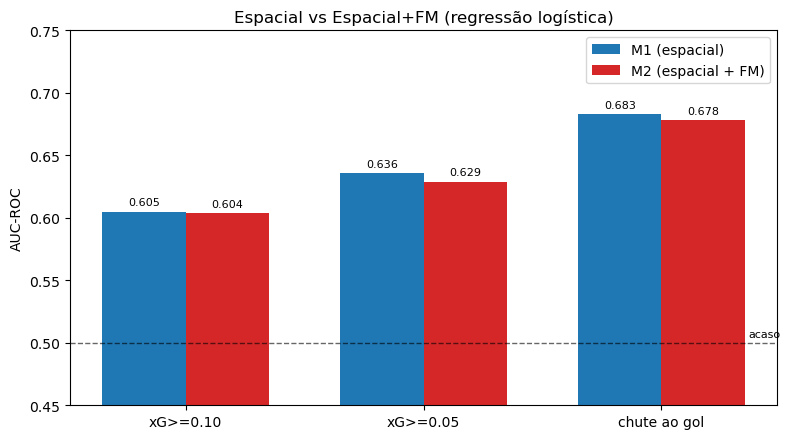

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(tab)); w = 0.35
ax.bar(x - w/2, tab['M1_AUC'], w, label='M1 (espacial)', color='#1f77b4')
ax.bar(x + w/2, tab['M2_AUC'], w, label='M2 (espacial + FM)', color='#d62728')
ax.axhline(0.5, color='k', ls='--', lw=1, alpha=0.6); ax.text(len(tab)-0.5, 0.505, 'acaso', fontsize=8, ha='right')
for i, r in tab.iterrows():
    ax.text(i - w/2, r['M1_AUC']+0.005, f"{r['M1_AUC']:.3f}", ha='center', fontsize=8)
    ax.text(i + w/2, r['M2_AUC']+0.005, f"{r['M2_AUC']:.3f}", ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(tab['cenario']); ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.45, 0.75); ax.set_title('Espacial vs Espacial+FM (regressão logística)'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Coeficientes do M2 (alvo `xG>=0.10`)

Features padronizadas → coeficientes **comparáveis** em magnitude. Coef > 0 puxa a
probabilidade de sucesso para cima. Em **vermelho**, as features do FM — se o peso
delas for ≈ 0, confirma que não contribuem.

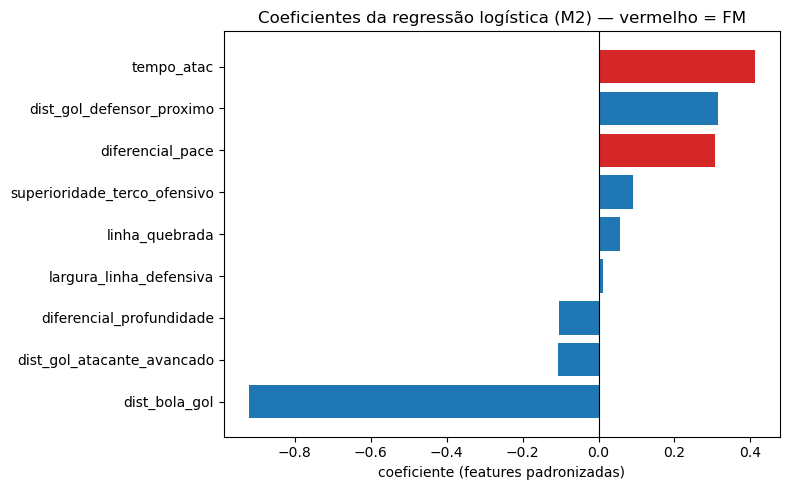

,feature,coef
0,dist_bola_gol,-0.921
7,tempo_atac,0.411
2,dist_gol_defensor_proximo,0.315
8,diferencial_pace,0.307
1,dist_gol_atacante_avancado,-0.108
3,diferencial_profundidade,-0.105
5,superioridade_terco_ofensivo,0.091
6,linha_quebrada,0.056
4,largura_linha_defensiva,0.013


In [5]:
y = TARGETS['xG>=0.10']
pipe = modelo().fit(comp[M2], y)
coef = pipe.named_steps['logisticregression'].coef_[0]
cdf = pd.DataFrame({'feature': M2, 'coef': coef}).sort_values('coef')

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#d62728' if f in FM else '#1f77b4' for f in cdf['feature']]
ax.barh(cdf['feature'], cdf['coef'], color=cores)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Coeficientes da regressão logística (M2) — vermelho = FM')
ax.set_xlabel('coeficiente (features padronizadas)')
plt.tight_layout(); plt.show()
display(cdf.reindex(cdf['coef'].abs().sort_values(ascending=False).index).round(3))

## 4. Conclusão

- **Modelo:** regressão logística nas linhas completas — melhor que HistGB/XGBoost
  nesta base (visto em comparação prévia).
- **Hipótese (FM agrega?):** julgar por `dAUC` e `wilcoxon_p` na tabela da Seção 2 e
  pela magnitude dos coeficientes do FM na Seção 3.
- **Pela evidência:** o sinal vem majoritariamente do **espacial** (distância ao gol);
  as features físicas do FM **não melhoram** o AUC (M2 ≈ M1, ΔAUC ≈ 0).
- **Limitações:** defensor = média da equipe (não o real do lance), apenas o frame
  inicial (sem trajetória), rótulo ruidoso e n≈580. O teto é de **dados**, não de modelo.